### Import

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

### Missing values process

In [91]:
train_df = pd.read_csv("Data/train.csv").drop(columns=['ID'])
test_df = pd.read_csv("Data/test.csv").drop(columns=['ID'])
train_X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

In [92]:
train_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 67 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   시술 시기 코드               256351 non-null  object 
 1   시술 당시 나이               256351 non-null  object 
 2   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 3   시술 유형                  256351 non-null  object 
 4   특정 시술 유형               256349 non-null  object 
 5   배란 자극 여부               256351 non-null  int64  
 6   배란 유도 유형               256351 non-null  object 
 7   단일 배아 이식 여부            250060 non-null  float64
 8   착상 전 유전 검사 사용 여부       2718 non-null    float64
 9   착상 전 유전 진단 사용 여부       250060 non-null  float64
 10  남성 주 불임 원인             256351 non-null  int64  
 11  남성 부 불임 원인             256351 non-null  int64  
 12  여성 주 불임 원인             256351 non-null  int64  
 13  여성 부 불임 원인             256351 non-null  int64  
 14  부부 주 불임 원인             256351 non-nu

In [93]:
def drop_high_missing_columns(df, threshold=0.5):
    missing_ratio = df.isnull().sum() / len(df)
    columns_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
    df_cleaned = df.drop(columns=columns_to_drop)
    return df_cleaned, columns_to_drop

In [94]:
# 결측치 비율 50% 넘는 열 삭제
train_cleaned, dropped_columns = drop_high_missing_columns(train_X, threshold=0.5)
print(dropped_columns)
test_cleaned, dropped_columns = drop_high_missing_columns(test_df, threshold=0.5)
print(dropped_columns)

['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']
['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']


In [95]:
train_missing_values = train_cleaned.isnull().sum()
train_missing_values = train_missing_values[train_missing_values > 0].sort_values(ascending=False)
test_missing_values = test_cleaned.isnull().sum()
test_missing_values = test_missing_values[test_missing_values > 0].sort_values(ascending=False)
print(train_missing_values)
print(test_missing_values)

난자 채취 경과일           57488
난자 혼합 경과일           53735
배아 이식 경과일           43566
수집된 신선 난자 수          6291
대리모 여부               6291
기증 배아 사용 여부          6291
신선 배아 사용 여부          6291
동결 배아 사용 여부          6291
기증자 정자와 혼합된 난자 수     6291
파트너 정자와 혼합된 난자 수     6291
혼합된 난자 수             6291
저장된 신선 난자 수          6291
해동 난자 수              6291
단일 배아 이식 여부          6291
해동된 배아 수             6291
미세주입 후 저장된 배아 수      6291
저장된 배아 수             6291
미세주입 배아 이식 수         6291
이식된 배아 수             6291
미세주입에서 생성된 배아 수      6291
미세주입된 난자 수           6291
총 생성 배아 수            6291
배아 생성 주요 이유          6291
착상 전 유전 진단 사용 여부     6291
특정 시술 유형                2
dtype: int64
난자 채취 경과일           19949
난자 혼합 경과일           18579
배아 이식 경과일           15246
착상 전 유전 진단 사용 여부     2176
대리모 여부               2176
기증 배아 사용 여부          2176
신선 배아 사용 여부          2176
동결 배아 사용 여부          2176
기증자 정자와 혼합된 난자 수     2176
파트너 정자와 혼합된 난자 수     2176
혼합된 난자 수             2176
저장된 신선 난자 수          2176
단일 배아 이식 여부          2176

In [96]:
di_cnt = train_cleaned[train_cleaned['시술 유형'] == 'DI'].shape[0]
print(di_cnt)
di_count = test_cleaned[test_cleaned['시술 유형'] == 'DI'].shape[0]
print(di_count)

6291
2176


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45212 (\N{HANGUL SYLLABLE NAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\

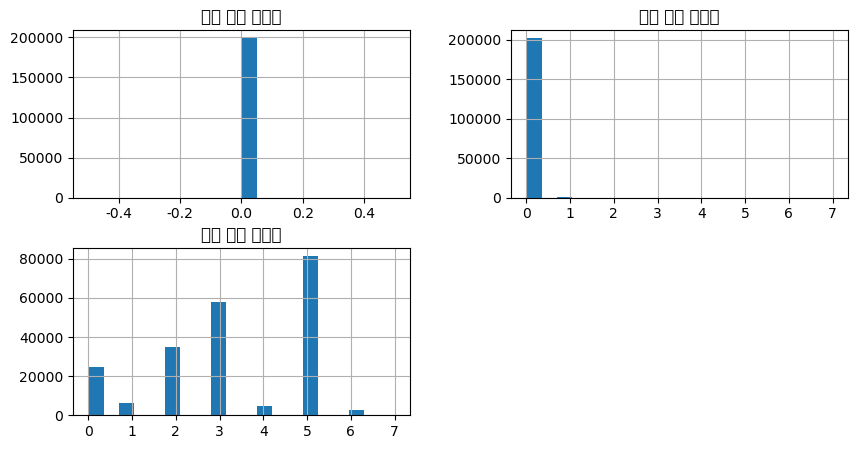

In [97]:
train_cleaned[['난자 채취 경과일','난자 혼합 경과일','배아 이식 경과일']].hist(figsize=(10, 5), bins=20)
plt.show()

In [98]:
train_cleaned.drop(columns=['난자 채취 경과일','난자 혼합 경과일'], inplace=True)
test_cleaned.drop(columns=['난자 채취 경과일','난자 혼합 경과일'], inplace=True)

In [99]:
# categorical과 numerical을 데이터 명세에 따라 분할 해도 되지만 결측치를 채우기 위해서는 문자형과 숫자형으로 나눠야 함.(unknown, -1 or 0)
categorical_cols = train_cleaned.select_dtypes(include=['object']).columns
numerical_cols = train_cleaned.select_dtypes(include=['float64','int64']).columns

#### DI(기증자 인공수정) 특징
- 남성 난임 요인, 원인 불명 난임, 기증 정자 사용, 인공수정
- 여성(대리모x)의 나이, 건강 상태, 기증된 정자의 질
- 시술 시기(배란일), 수정 횟수
- 혼합된 난자(IVF의 경우만 확인), 배아x, 미세주입x, 착상 전 유전 진단(배아)
- 기증자 정자를 사용하지만 혼합된(수정) 난자의 수는 알 수 없음

In [100]:
# DI이면 무조건 0 -> 배아 이식 x
train_cleaned.loc[train_cleaned['시술 유형'] == 'DI', '배아 이식 경과일'] = 0
test_cleaned.loc[test_cleaned['시술 유형'] == 'DI', '배아 이식 경과일'] = 0

In [101]:
# 특정 시술 유형을 제외하고는 DI 관련 결측치
train_missing_values = train_missing_values[train_missing_values > 0].sort_values(ascending=False)
missing_columns = train_missing_values.index.tolist()
missing_num = [col for col in missing_columns if col in numerical_cols]
missing_cat = [col for col in missing_columns if col in categorical_cols]
print('num:', missing_num)
print('cat:', missing_cat)

num: ['배아 이식 경과일', '해동된 배아 수', '착상 전 유전 진단 사용 여부', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동 난자 수', '단일 배아 이식 여부', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', '수집된 신선 난자 수']
cat: ['배아 생성 주요 이유', '특정 시술 유형']


#### numerical 결측치 처리(전부 0)

In [102]:
# '배아 이식 경과일'을 제외한 숫자형 변수 선택
numerical_cols_excluding_target = [col for col in numerical_cols if col != '배아 이식 경과일']

# '배아 이식 경과일'을 제외한 숫자형 변수의 결측치 0으로 채우기
train_cleaned[numerical_cols_excluding_target] = train_cleaned[numerical_cols_excluding_target].fillna(0)
test_cleaned[numerical_cols_excluding_target] = test_cleaned[numerical_cols_excluding_target].fillna(0)

#### categorical 결측치 처리

In [103]:
# DI는 배아를 생성하지 않음.
train_cleaned['배아 생성 주요 이유'] = train_cleaned['배아 생성 주요 이유'].fillna('Unknown')
train_cleaned['특정 시술 유형'] = train_cleaned['특정 시술 유형'].fillna('Unknown')

test_cleaned['배아 생성 주요 이유'] = test_cleaned['배아 생성 주요 이유'].fillna('Unknown')

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46976 (\N{HANGUL SYLLABLE RAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48512 (\N{HANG

배아 이식 경과일             1.000000
신선 배아 사용 여부           0.723475
총 생성 배아 수             0.665238
혼합된 난자 수              0.647397
수집된 신선 난자 수           0.599273
파트너 정자와 혼합된 난자 수      0.586844
배란 자극 여부              0.574332
미세주입에서 생성된 배아 수       0.412049
미세주입된 난자 수            0.390011
저장된 배아 수              0.338121
단일 배아 이식 여부           0.262534
미세주입 후 저장된 배아 수       0.238431
미세주입 배아 이식 수          0.174301
기증자 정자와 혼합된 난자 수      0.114753
이식된 배아 수              0.069870
불명확 불임 원인             0.060625
해동 난자 수               0.026336
불임 원인 - 배란 장애         0.010882
착상 전 유전 진단 사용 여부      0.009407
불임 원인 - 남성 요인         0.006479
저장된 신선 난자 수          -0.000972
불임 원인 - 정자 면역학적 요인   -0.001397
불임 원인 - 자궁경부 문제      -0.002988
불임 원인 - 정자 운동성       -0.006390
불임 원인 - 난관 질환        -0.008729
불임 원인 - 정자 형태        -0.010120
불임 원인 - 자궁내막증        -0.012319
불임 원인 - 정자 농도        -0.022526
기증 배아 사용 여부          -0.034875
대리모 여부               -0.046609
부부 부 불임 원인           -0.064974
여성 부 불임 원인           -0.075891
남성 부 불임 

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

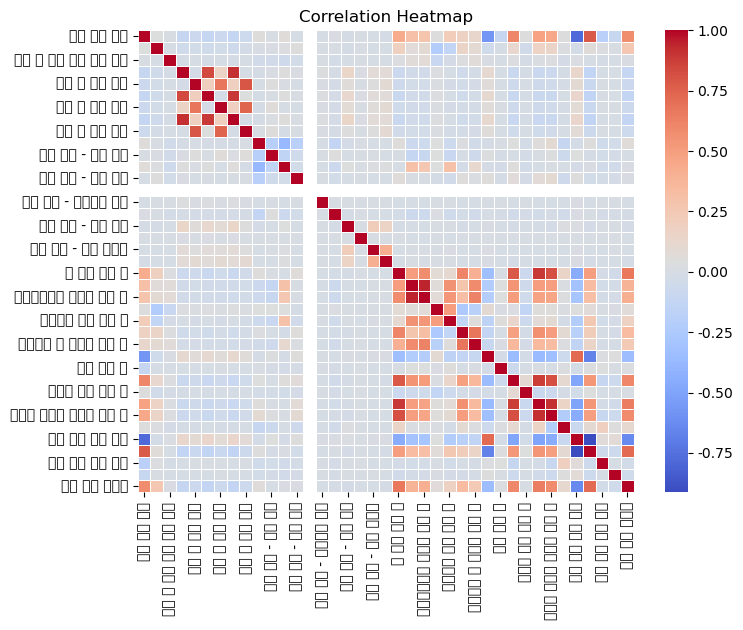

In [104]:
corr = train_cleaned[numerical_cols].corr()
corr_target = corr["배아 이식 경과일"].sort_values(ascending=False)
print(corr_target)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# 배아 이식 경과일 결측치 채우기(기존 데이터 분포 유지)
threshold = 0.5
target = '배아 이식 경과일'
sel_feature = corr_target[abs(corr[target]) > threshold].index.tolist()
sel_feature.remove(target)
print(f"KNN에 사용할 Feature: {sel_feature}")
train_knn = train_cleaned[[target] + sel_feature]  
test_knn = test_cleaned[[target] + sel_feature]  
imputer = KNNImputer(n_neighbors=5)
train_imputed = imputer.fit_transform(train_knn)
test_imputed = imputer.transform(test_knn)
train_cleaned[target] = train_imputed[:, 0]  # 첫 번째 열이 Target
test_cleaned[target] = test_imputed[:, 0]
train_cleaned[target] = train_cleaned[target].round().astype(int)
test_cleaned[target] = test_cleaned[target].round().astype(int)

KNN에 사용할 Feature: ['신선 배아 사용 여부', '총 생성 배아 수', '혼합된 난자 수', '수집된 신선 난자 수', '파트너 정자와 혼합된 난자 수', '배란 자극 여부', '동결 배아 사용 여부']


### 결측치 시각화

In [106]:
print(train_cleaned.isnull().sum())
print(test_cleaned.isnull().sum())

시술 시기 코드              0
시술 당시 나이              0
시술 유형                 0
특정 시술 유형              0
배란 자극 여부              0
배란 유도 유형              0
단일 배아 이식 여부           0
착상 전 유전 진단 사용 여부      0
남성 주 불임 원인            0
남성 부 불임 원인            0
여성 주 불임 원인            0
여성 부 불임 원인            0
부부 주 불임 원인            0
부부 부 불임 원인            0
불명확 불임 원인             0
불임 원인 - 난관 질환         0
불임 원인 - 남성 요인         0
불임 원인 - 배란 장애         0
불임 원인 - 여성 요인         0
불임 원인 - 자궁경부 문제       0
불임 원인 - 자궁내막증         0
불임 원인 - 정자 농도         0
불임 원인 - 정자 면역학적 요인    0
불임 원인 - 정자 운동성        0
불임 원인 - 정자 형태         0
배아 생성 주요 이유           0
총 시술 횟수               0
클리닉 내 총 시술 횟수         0
IVF 시술 횟수             0
DI 시술 횟수              0
총 임신 횟수               0
IVF 임신 횟수             0
DI 임신 횟수              0
총 출산 횟수               0
IVF 출산 횟수             0
DI 출산 횟수              0
총 생성 배아 수             0
미세주입된 난자 수            0
미세주입에서 생성된 배아 수       0
이식된 배아 수              0
미세주입 배아 이식 수          0
저장된 배아 수        

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Font family 'NanumGothic' not found.
d:\env\envs\aimers\Lib\site-packages\seaborn\ut

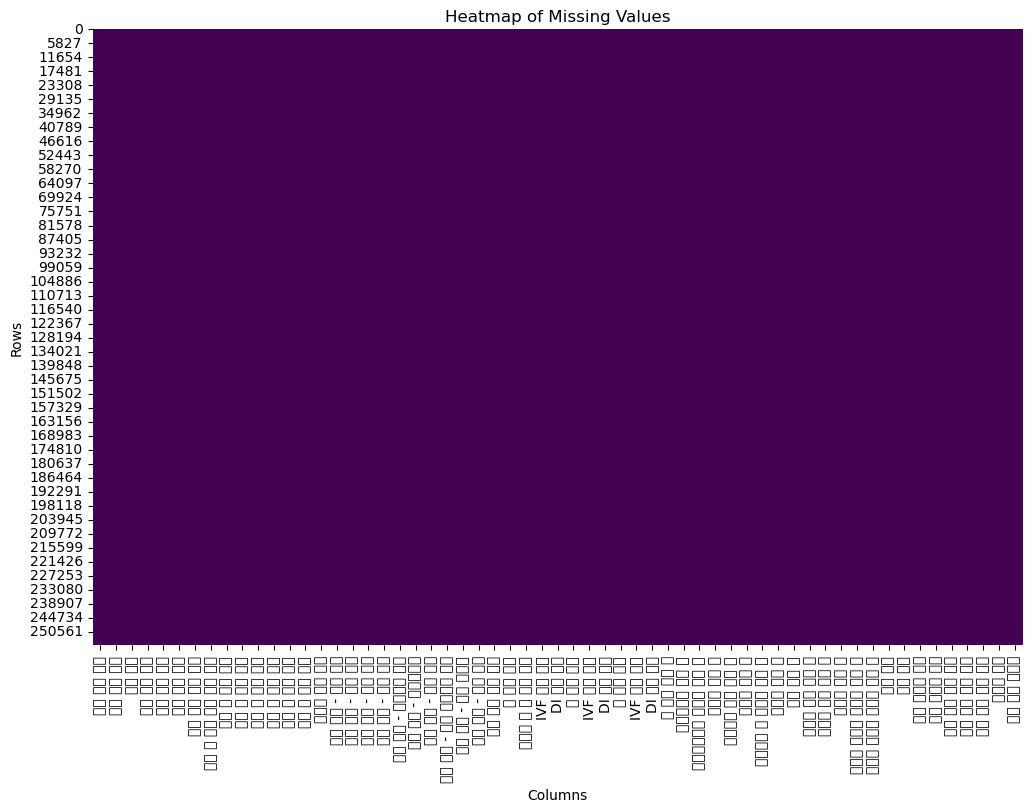

In [107]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### 저장

In [113]:
train_cleaned['임신 성공 여부'] = y
train_cleaned.to_csv('train_cleaned.csv', index=False, encoding='utf-8-sig')

In [115]:
test_cleaned.to_csv('test_cleaned.csv', index=False, encoding='utf-8-sig')

<Axes: >

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

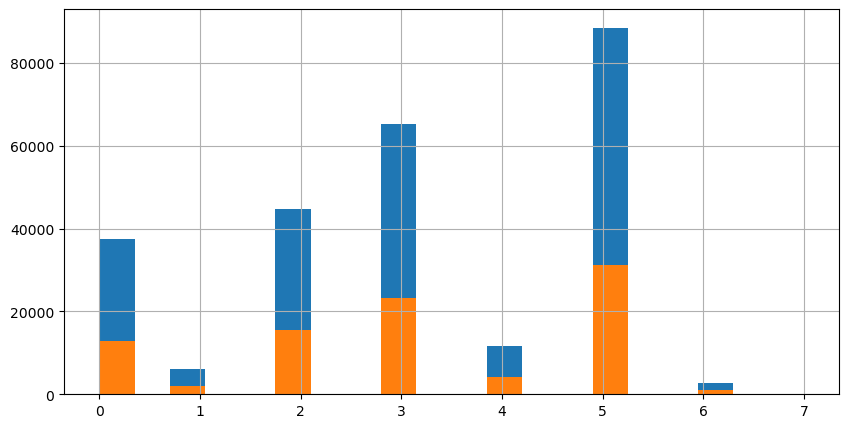

In [114]:
train_cleaned['배아 이식 경과일'].hist(figsize=(10, 5), bins=20)
test_cleaned['배아 이식 경과일'].hist(figsize=(10, 5), bins=20)